# 01 — YouBike Data Exploration

This notebook performs the first inspection of the official Taipei YouBike 2.0 real-time station data.

> Note: this file is a single snapshot. It describes station availability at one point in time; it is not yet a historical demand dataset.

## 1. Import libraries and locate the data

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Support running Jupyter from either the repository root or notebooks/.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_path = project_root / "data" / "raw" / "youbike_immediate_sample.json"

if not data_path.exists():
    raise FileNotFoundError(f"Data file not found: {data_path}")

data_path

Matplotlib is building the font cache; this may take a moment.


PosixPath('/Users/xander/Documents/GitHub/youbike-demand-prediction/data/raw/youbike_immediate_sample.json')

## 2. Load the JSON data with pandas

In [2]:
df = pd.read_json(data_path)
df.head()

,sno,sna,sarea,mday,ar,sareaen,snaen,aren,act,srcUpdateTime,updateTime,infoTime,infoDate,Quantity,available_rent_bikes,latitude,longitude,available_return_bikes
0,500101001,YouBike2.0_捷運科技大樓站,大安區,2026-08-20 19:39:02,復興南路二段235號前,Daan Dist.,YouBike2.0_MRT Technology Bldg. Sta.,No.235， Sec. 2， Fuxing S. Rd.,1,2026-08-20 19:41:52,2026-08-20 19:41:52,2026-08-20 19:39:02,2026-08-20,28,24,25.02605,121.54360,4
1,500101002,YouBike2.0_復興南路二段273號前,大安區,2026-08-20 19:39:02,復興南路二段273號西側,Daan Dist.,YouBike2.0_No.273， Sec. 2， Fuxing S. Rd.,No.273， Sec. 2， Fuxing S. Rd. (West),1,2026-08-20 19:41:52,2026-08-20 19:41:52,2026-08-20 19:39:02,2026-08-20,21,19,25.02565,121.54357,1
2,500101003,YouBike2.0_國北教大實小東側門,大安區,2026-08-20 19:32:02,和平東路二段96巷7號,Daan Dist.,YouBike2.0_NTUE Experiment Elementary School (...,No. 7， Ln. 96， Sec. 2， Heping E. Rd,1,2026-08-20 19:41:52,2026-08-20 19:41:52,2026-08-20 19:32:02,2026-08-20,28,11,25.02429,121.54124,17
3,500101004,YouBike2.0_和平公園東側,大安區,2026-08-20 19:38:03,和平東路二段118巷33號,Daan Dist.,YouBike2.0_Heping Park (East),No. 33， Ln. 118， Sec. 2， Heping E. Rd,1,2026-08-20 19:41:52,2026-08-20 19:41:52,2026-08-20 19:38:03,2026-08-20,11,3,25.02351,121.54282,8
4,500101005,YouBike2.0_辛亥復興路口西北側,大安區,2026-08-20 19:34:03,復興南路二段368號,Daan Dist.,YouBike2.0_Xinhai Fuxing Rd. Intersection (Nor...,No. 368， Sec. 2， Fuxing S. Rd.,1,2026-08-20 19:41:52,2026-08-20 19:41:52,2026-08-20 19:34:03,2026-08-20,16,1,25.02153,121.54299,15


## 3. Inspect shape, columns, and data types

In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.info()

Rows: 1,790
Columns: 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1790 entries, 0 to 1789
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sno                     1790 non-null   int64  
 1   sna                     1790 non-null   object 
 2   sarea                   1790 non-null   object 
 3   mday                    1790 non-null   object 
 4   ar                      1790 non-null   object 
 5   sareaen                 1790 non-null   object 
 6   snaen                   1790 non-null   object 
 7   aren                    1790 non-null   object 
 8   act                     1790 non-null   int64  
 9   srcUpdateTime           1790 non-null   object 
 10  updateTime              1790 non-null   object 
 11  infoTime                1790 non-null   object 
 12  infoDate                1790 non-null   object 
 13  Quantity                1790 non-null   int64  
 14  available_rent_b

In [4]:
column_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "unique_values": df.nunique(dropna=False).values,
})
column_summary

,column,dtype,unique_values
0,sno,int64,1790
1,sna,object,1790
2,sarea,object,13
3,mday,object,267
4,ar,object,1790
5,sareaen,object,13
6,snaen,object,1781
7,aren,object,1786
8,act,int64,2
9,srcUpdateTime,object,1


## 4. Check missing values and duplicate station IDs

In [5]:
missing_summary = (
    df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)
missing_summary["missing_percent"] = (
    missing_summary["missing_count"] / len(df) * 100
).round(2)
missing_summary

,missing_count,missing_percent
sno,0,0.0
sna,0,0.0
sarea,0,0.0
mday,0,0.0
ar,0,0.0
sareaen,0,0.0
snaen,0,0.0
aren,0,0.0
act,0,0.0
srcUpdateTime,0,0.0


In [6]:
station_id_column = "sno"
if station_id_column in df.columns:
    duplicate_station_ids = df[station_id_column].duplicated().sum()
    print(f"Duplicate station IDs: {duplicate_station_ids}")
else:
    print(f"Station ID column '{station_id_column}' was not found.")

Duplicate station IDs: 0


## 5. Descriptive statistics

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sno,1790.0,NaN,NaN,NaN,500107525.668156,4070.60681,500101001.0,500104153.25,500107187.5,500110068.75,500119102.0
sna,1790,1790,YouBike2.0_捷運科技大樓站,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sarea,1790,13,內湖區,226,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mday,1790,267,2026-08-20 19:41:03,149,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ar,1790,1790,復興南路二段235號前,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sareaen,1790,13,Neihu Dist,226,NaN,NaN,NaN,NaN,NaN,NaN,NaN
snaen,1790,1781,YouBike2.0_XiangAn Public Housing,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aren,1790,1786,No. 259， Daye Rd. (Opposite),2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
act,1790.0,NaN,NaN,NaN,0.983799,0.126284,0.0,1.0,1.0,1.0,1.0
srcUpdateTime,1790,1,2026-08-20 19:41:52,1790,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6. First visualization

The chart shows the number of stations in each Taipei district in this snapshot.

/var/folders/ks/w1ns79m97v73dhf2r3q6_zm00000gn/T/ipykernel_32518/1846809606.py:14: UserWarning: Glyph 33274 (\N{CJK UNIFIED IDEOGRAPH-81FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ks/w1ns79m97v73dhf2r3q6_zm00000gn/T/ipykernel_32518/1846809606.py:14: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ks/w1ns79m97v73dhf2r3q6_zm00000gn/T/ipykernel_32518/1846809606.py:14: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ks/w1ns79m97v73dhf2r3q6_zm00000gn/T/ipykernel_32518/1846809606.py:14: UserWarning: Glyph 39208 (\N{CJK UNIFIED IDEOGRAPH-9928}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ks/w1ns79m97v73dhf2r3q6_zm00000gn/T/ipykernel_32518/1846809606.py:14: UserWarning: Glyph 26657 (\N{CJK UNIFIED IDEOGRAPH-6821}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ks/w1ns

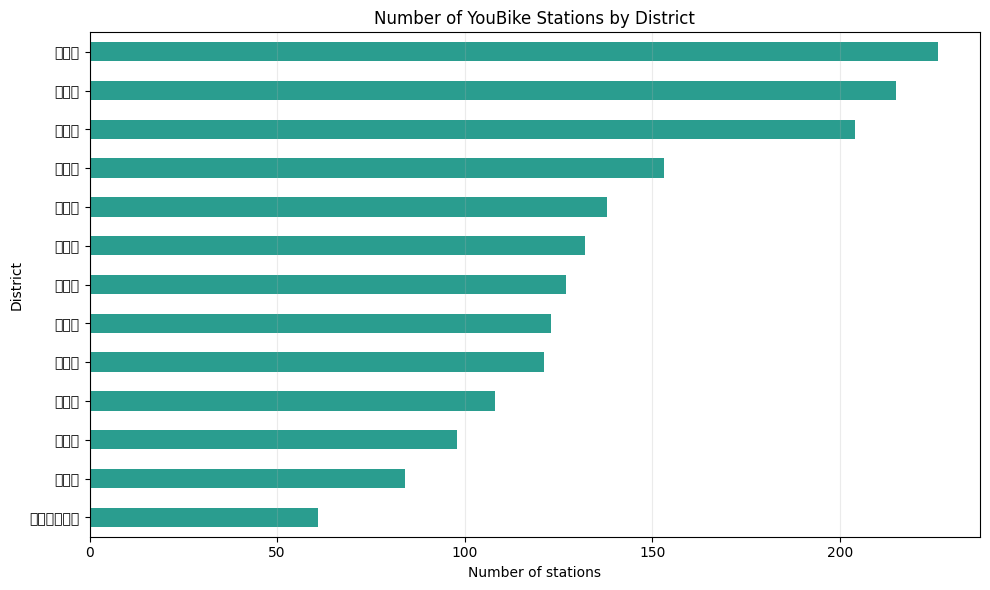

In [8]:
district_column = "sarea"

if district_column not in df.columns:
    raise KeyError(f"Required column '{district_column}' was not found.")

stations_by_district = df[district_column].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
stations_by_district.plot(kind="barh", ax=ax, color="#2A9D8F")
ax.set_title("Number of YouBike Stations by District")
ax.set_xlabel("Number of stations")
ax.set_ylabel("District")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## Initial observations

- Each row represents one YouBike station in a single real-time snapshot.
- The data includes station capacity, available bikes, return spaces, location, status, and update times.
- Multiple snapshots collected over time will be required before short-term demand can be calculated or predicted.